In [7]:
# Importiamo le librerie necessarie
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Carichiamo il file Excel
df = pd.read_excel('../data/Volve production data.xlsx')

# Prima occhiata ai dati
print("Dimensioni del dataset:", df.shape)
print("\nPrime 5 righe:")
df.head()

Dimensioni del dataset: (15634, 24)

Prime 5 righe:


,DATEPRD,WELL_BORE_CODE,NPD_WELL_BORE_CODE,NPD_WELL_BORE_NAME,NPD_FIELD_CODE,NPD_FIELD_NAME,NPD_FACILITY_CODE,NPD_FACILITY_NAME,ON_STREAM_HRS,AVG_DOWNHOLE_PRESSURE,...,AVG_CHOKE_UOM,AVG_WHP_P,AVG_WHT_P,DP_CHOKE_SIZE,BORE_OIL_VOL,BORE_GAS_VOL,BORE_WAT_VOL,BORE_WI_VOL,FLOW_KIND,WELL_TYPE
0,2014-04-07,NO 15/9-F-1 C,7405,15/9-F-1 C,3420717,VOLVE,369304,MÆRSK INSPIRER,0.0,0.00000,...,%,0.00000,0.00000,0.00000,0.0,0.0,0.0,NaN,production,WI
1,2014-04-08,NO 15/9-F-1 C,7405,15/9-F-1 C,3420717,VOLVE,369304,MÆRSK INSPIRER,0.0,NaN,...,%,0.00000,0.00000,0.00000,0.0,0.0,0.0,NaN,production,OP
2,2014-04-09,NO 15/9-F-1 C,7405,15/9-F-1 C,3420717,VOLVE,369304,MÆRSK INSPIRER,0.0,NaN,...,%,0.00000,0.00000,0.00000,0.0,0.0,0.0,NaN,production,OP
3,2014-04-10,NO 15/9-F-1 C,7405,15/9-F-1 C,3420717,VOLVE,369304,MÆRSK INSPIRER,0.0,NaN,...,%,0.00000,0.00000,0.00000,0.0,0.0,0.0,NaN,production,OP
4,2014-04-11,NO 15/9-F-1 C,7405,15/9-F-1 C,3420717,VOLVE,369304,MÆRSK INSPIRER,0.0,310.37614,...,%,33.09788,10.47992,33.07195,0.0,0.0,0.0,NaN,production,OP


In [8]:
# Quanti pozzi unici ci sono?
print("Pozzi nel dataset:")
print(df['WELL_BORE_CODE'].unique())

print("\nRange temporale:")
print("Dal:", df['DATEPRD'].min())
print("Al:", df['DATEPRD'].max())

print("\nTotale righe (giorni di produzione):", len(df))

Pozzi nel dataset:
['NO 15/9-F-1 C' 'NO 15/9-F-11 H' 'NO 15/9-F-12 H' 'NO 15/9-F-14 H'
 'NO 15/9-F-15 D' 'NO 15/9-F-4 AH' 'NO 15/9-F-5 AH']

Range temporale:
Dal: 2007-09-01 00:00:00
Al: 2016-12-01 00:00:00

Totale righe (giorni di produzione): 15634


In [9]:
# Vediamo tutte le colonne disponibili
print("Colonne del dataset:")
for col in df.columns:
    print(f"  {col}")

Colonne del dataset:
  DATEPRD
  WELL_BORE_CODE
  NPD_WELL_BORE_CODE
  NPD_WELL_BORE_NAME
  NPD_FIELD_CODE
  NPD_FIELD_NAME
  NPD_FACILITY_CODE
  NPD_FACILITY_NAME
  ON_STREAM_HRS
  AVG_DOWNHOLE_PRESSURE
  AVG_DOWNHOLE_TEMPERATURE
  AVG_DP_TUBING
  AVG_ANNULUS_PRESS
  AVG_CHOKE_SIZE_P
  AVG_CHOKE_UOM
  AVG_WHP_P
  AVG_WHT_P
  DP_CHOKE_SIZE
  BORE_OIL_VOL
  BORE_GAS_VOL
  BORE_WAT_VOL
  BORE_WI_VOL
  FLOW_KIND
  WELL_TYPE


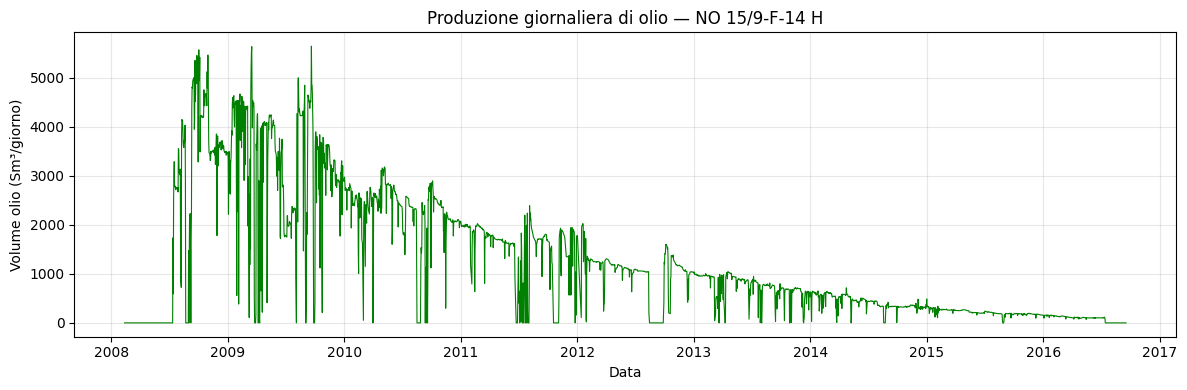

In [10]:
# Filtriamo un pozzo e plottiamo la produzione di olio
pozzo = 'NO 15/9-F-14 H'
df_pozzo = df[df['WELL_BORE_CODE'] == pozzo].copy()
df_pozzo = df_pozzo.sort_values('DATEPRD')

# Plot produzione olio
plt.figure(figsize=(12, 4))
plt.plot(df_pozzo['DATEPRD'], df_pozzo['BORE_OIL_VOL'], color='green', linewidth=0.8)
plt.title(f'Produzione giornaliera di olio — {pozzo}')
plt.xlabel('Data')
plt.ylabel('Volume olio (Sm³/giorno)')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

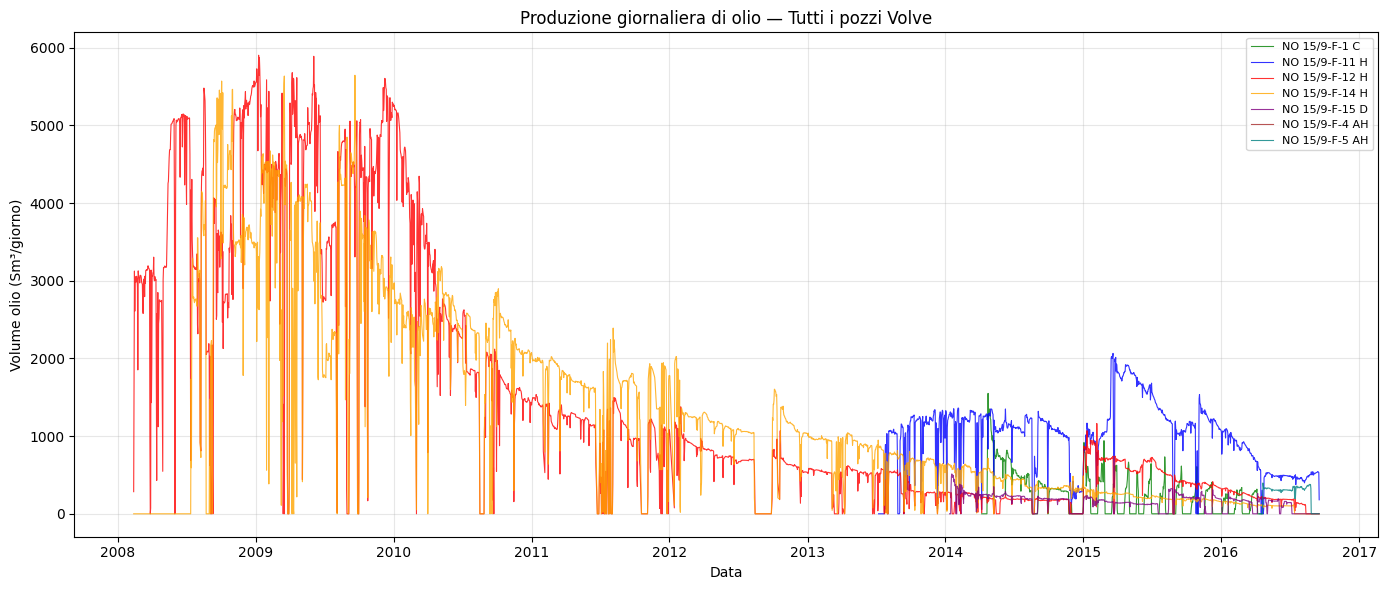

In [11]:
# Produzione di olio per tutti i pozzi a confronto
pozzi = df['WELL_BORE_CODE'].unique()
colors = ['green', 'blue', 'red', 'orange', 'purple', 'brown', 'teal']

plt.figure(figsize=(14, 6))
for i, pozzo in enumerate(pozzi):
    df_p = df[df['WELL_BORE_CODE'] == pozzo].sort_values('DATEPRD')
    plt.plot(df_p['DATEPRD'], df_p['BORE_OIL_VOL'], 
             label=pozzo, color=colors[i], linewidth=0.8, alpha=0.8)

plt.title('Produzione giornaliera di olio — Tutti i pozzi Volve')
plt.xlabel('Data')
plt.ylabel('Volume olio (Sm³/giorno)')
plt.legend(fontsize=8, loc='upper right')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

In [12]:
# Valori mancanti per i pozzi target
pozzi_target = ['NO 15/9-F-12 H', 'NO 15/9-F-14 H', 'NO 15/9-F-11 H']
colonne_utili = ['DATEPRD', 'BORE_OIL_VOL', 'BORE_GAS_VOL', 
                 'BORE_WAT_VOL', 'AVG_DOWNHOLE_PRESSURE', 
                 'AVG_CHOKE_SIZE_P', 'ON_STREAM_HRS']

df_target = df[df['WELL_BORE_CODE'].isin(pozzi_target)][colonne_utili + ['WELL_BORE_CODE']]

print("Valori mancanti per pozzo:")
for pozzo in pozzi_target:
    df_p = df_target[df_target['WELL_BORE_CODE'] == pozzo]
    print(f"\n{pozzo} ({len(df_p)} giorni):")
    print(df_p[colonne_utili].isnull().sum())

Valori mancanti per pozzo:

NO 15/9-F-12 H (3056 giorni):
DATEPRD                   0
BORE_OIL_VOL              0
BORE_GAS_VOL              0
BORE_WAT_VOL              0
AVG_DOWNHOLE_PRESSURE     6
AVG_CHOKE_SIZE_P         44
ON_STREAM_HRS             0
dtype: int64

NO 15/9-F-14 H (3056 giorni):
DATEPRD                    0
BORE_OIL_VOL               0
BORE_GAS_VOL               0
BORE_WAT_VOL               0
AVG_DOWNHOLE_PRESSURE      6
AVG_CHOKE_SIZE_P         196
ON_STREAM_HRS              0
dtype: int64

NO 15/9-F-11 H (1165 giorni):
DATEPRD                  0
BORE_OIL_VOL             0
BORE_GAS_VOL             0
BORE_WAT_VOL             0
AVG_DOWNHOLE_PRESSURE    6
AVG_CHOKE_SIZE_P         2
ON_STREAM_HRS            0
dtype: int64


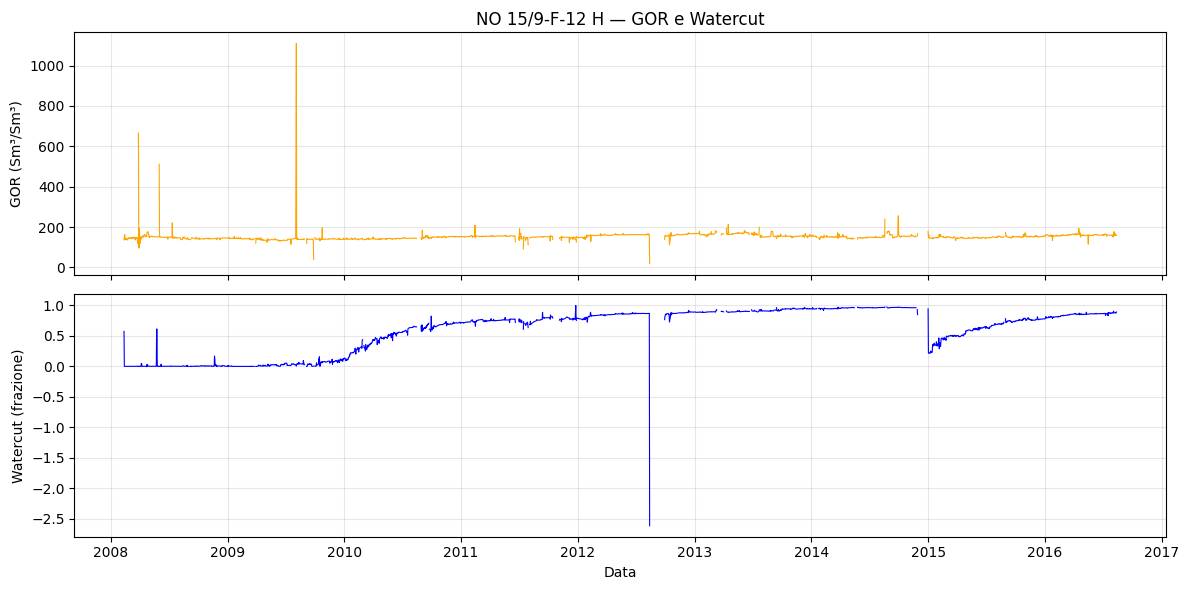

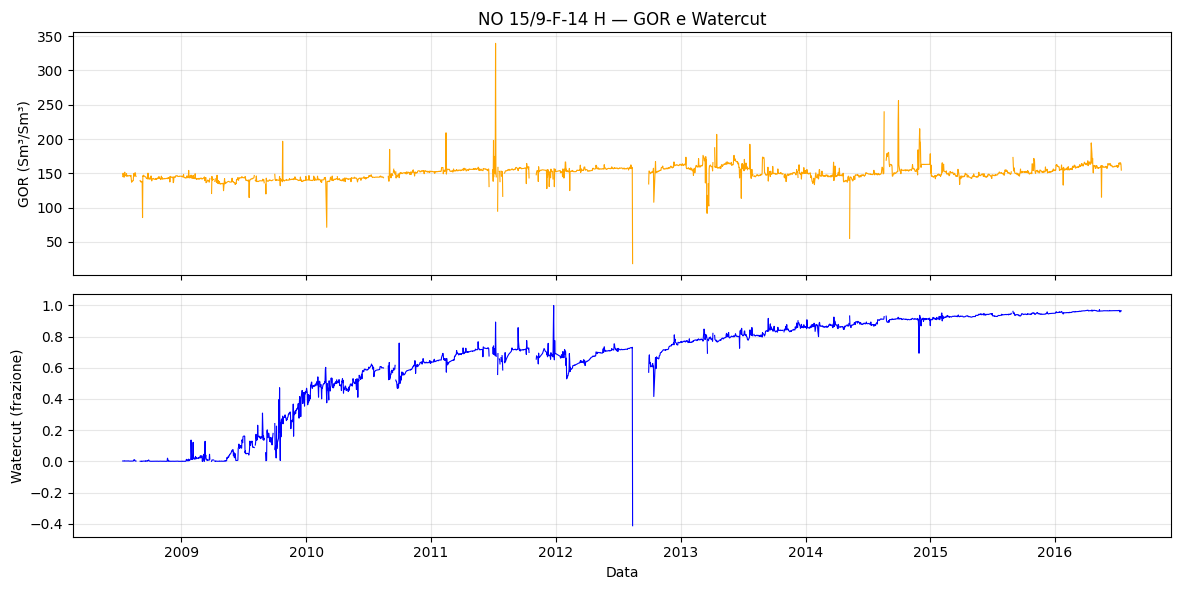

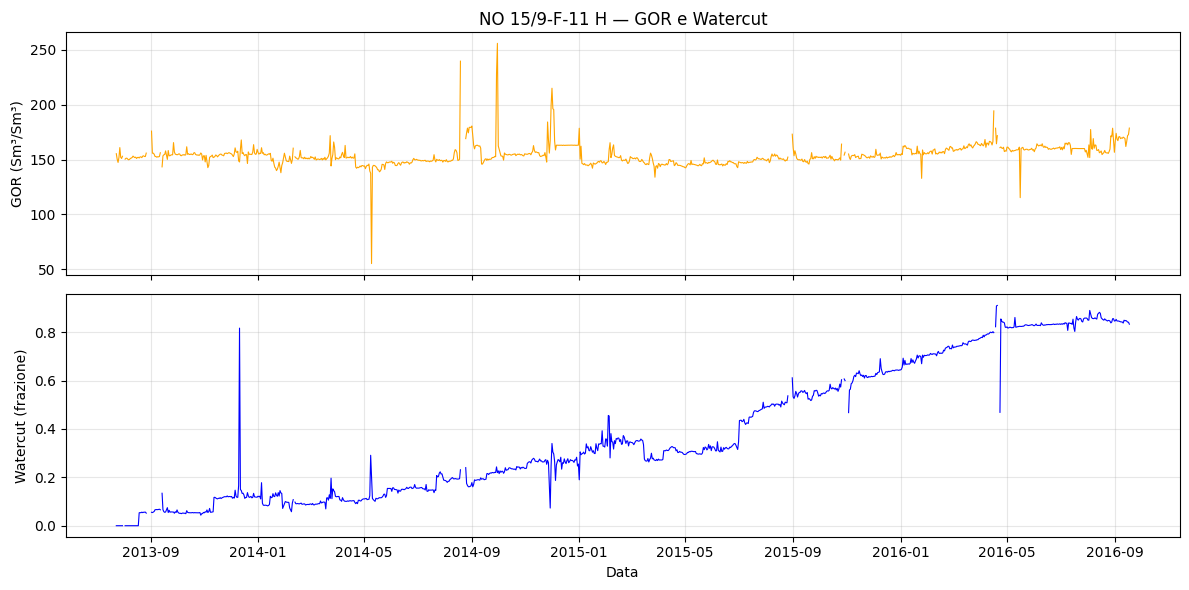

In [13]:
# Calcoliamo GOR e Watercut per i pozzi target
for pozzo in pozzi_target:
    df_p = df_target[df_target['WELL_BORE_CODE'] == pozzo].copy()
    df_p = df_p.sort_values('DATEPRD')
    
    # Evitiamo divisioni per zero
    df_p['GOR'] = df_p.apply(lambda r: r['BORE_GAS_VOL']/r['BORE_OIL_VOL'] 
                              if r['BORE_OIL_VOL'] > 0 else np.nan, axis=1)
    df_p['WATERCUT'] = df_p.apply(lambda r: r['BORE_WAT_VOL']/(r['BORE_OIL_VOL']+r['BORE_WAT_VOL']) 
                                   if (r['BORE_OIL_VOL']+r['BORE_WAT_VOL']) > 0 else np.nan, axis=1)
    
    fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(12, 6), sharex=True)
    
    ax1.plot(df_p['DATEPRD'], df_p['GOR'], color='orange', linewidth=0.8)
    ax1.set_ylabel('GOR (Sm³/Sm³)')
    ax1.set_title(f'{pozzo} — GOR e Watercut')
    ax1.grid(True, alpha=0.3)
    
    ax2.plot(df_p['DATEPRD'], df_p['WATERCUT'], color='blue', linewidth=0.8)
    ax2.set_ylabel('Watercut (frazione)')
    ax2.set_xlabel('Data')
    ax2.grid(True, alpha=0.3)
    
    plt.tight_layout()
    plt.show()
    